In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
data = pd.read_csv("ner_dataset.csv", encoding="latin1").ffill()

words = list(data["Word"].unique())
tags = list(data["Tag"].unique())

# Add special tokens
if "ENDPAD" not in words:
    words.append("ENDPAD")

if "PAD" not in tags:
    tags.append("PAD")

# Create mappings
word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

In [10]:
data.head(50)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


In [11]:
print("Unique words:", len(words))
print("Unique tags:", len(tags))

Unique words: 13680
Unique tags: 18


In [12]:
print("Unique tags are:", tags)

Unique tags are: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat', 'PAD']


In [13]:
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #", group_keys=False).apply(
            lambda s: [(w, t) for w, t in zip(s["Word"], s["Tag"])]
        )
        self.sentences = list(self.grouped)

getter = SentenceGetter(data)
sentences = getter.sentences

In [14]:
sentences[35]

[('On', 'O'),
 ('Friday', 'B-tim'),
 (',', 'O'),
 ('five', 'O'),
 ('soldiers', 'O'),
 ('were', 'O'),
 ('killed', 'O'),
 ('when', 'O'),
 ('dozens', 'O'),
 ('of', 'O'),
 ('militants', 'O'),
 ('stormed', 'O'),
 ('a', 'O'),
 ('military', 'O'),
 ('checkpoint', 'O'),
 ('in', 'O'),
 ('Orakzai', 'B-geo'),
 ('.', 'O')]

In [15]:
X = [[word2idx[w] for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

In [16]:
word2idx

{'Thousands': 1,
 'of': 2,
 'demonstrators': 3,
 'have': 4,
 'marched': 5,
 'through': 6,
 'London': 7,
 'to': 8,
 'protest': 9,
 'the': 10,
 'war': 11,
 'in': 12,
 'Iraq': 13,
 'and': 14,
 'demand': 15,
 'withdrawal': 16,
 'British': 17,
 'troops': 18,
 'from': 19,
 'that': 20,
 'country': 21,
 '.': 22,
 'Families': 23,
 'soldiers': 24,
 'killed': 25,
 'conflict': 26,
 'joined': 27,
 'protesters': 28,
 'who': 29,
 'carried': 30,
 'banners': 31,
 'with': 32,
 'such': 33,
 'slogans': 34,
 'as': 35,
 '"': 36,
 'Bush': 37,
 'Number': 38,
 'One': 39,
 'Terrorist': 40,
 'Stop': 41,
 'Bombings': 42,
 'They': 43,
 'Houses': 44,
 'Parliament': 45,
 'a': 46,
 'rally': 47,
 'Hyde': 48,
 'Park': 49,
 'Police': 50,
 'put': 51,
 'number': 52,
 'marchers': 53,
 'at': 54,
 '10,000': 55,
 'while': 56,
 'organizers': 57,
 'claimed': 58,
 'it': 59,
 'was': 60,
 '1,00,000': 61,
 'The': 62,
 'comes': 63,
 'on': 64,
 'eve': 65,
 'annual': 66,
 'conference': 67,
 'Britain': 68,
 "'s": 69,
 'ruling': 70,
 'L

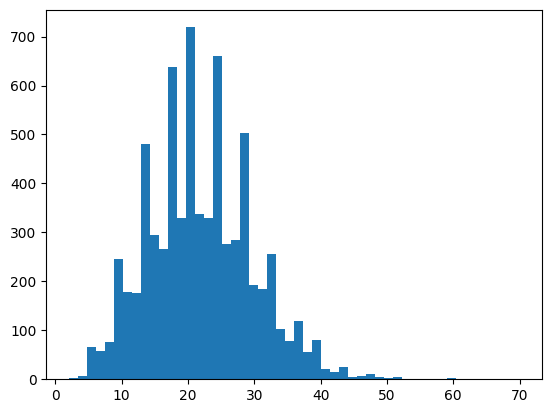

In [17]:
plt.hist([len(s) for s in sentences], bins=50)
plt.show()

In [18]:
# Pad sequences
max_len = 50

X_pad = pad_sequence(
    [torch.tensor(seq) for seq in X],
    batch_first=True,
    padding_value=word2idx["ENDPAD"]
)

y_pad = pad_sequence(
    [torch.tensor(seq) for seq in y],
    batch_first=True,
    padding_value=tag2idx["PAD"]
)

# Trim
X_pad = X_pad[:, :max_len]
y_pad = y_pad[:, :max_len]

In [19]:
X_pad[0]

tensor([    1,     2,     3,     4,     5,     6,     7,     8,     9,    10,
           11,    12,    13,    14,    15,    10,    16,     2,    17,    18,
           19,    20,    21,    22, 13680, 13680, 13680, 13680, 13680, 13680,
        13680, 13680, 13680, 13680, 13680, 13680, 13680, 13680, 13680, 13680,
        13680, 13680, 13680, 13680, 13680, 13680, 13680, 13680, 13680, 13680])

In [20]:
y_pad[0]

tensor([ 0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,
         2,  0,  0,  0,  0,  0, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
        17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_pad, test_size=0.2, random_state=1
)

In [22]:
# Dataset class
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=32)

In [23]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=100, hidden_dim=128):
        super(BiLSTMTagger, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size + 1,
            embedding_dim,
            padding_idx=word2idx["ENDPAD"]
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x

In [24]:
model = BiLSTMTagger(len(word2idx), len(tag2idx)).to(device)
loss_fn = nn.CrossEntropyLoss(ignore_index=tag2idx["PAD"])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
def train_model(model, train_loader, test_loader, epochs=10):
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids)

            loss = loss_fn(
                outputs.view(-1, len(tag2idx)),
                labels.view(-1)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids)

                loss = loss_fn(
                    outputs.view(-1, len(tag2idx)),
                    labels.view(-1)
                )

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f}")
  return train_losses, val_losses


In [32]:
def evaluate_model(model, test_loader):
    model.eval()
    true_tags, pred_tags = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)

            for i in range(len(labels)):
                for j in range(len(labels[i])):
                    if labels[i][j] != tag2idx["PAD"]:
                        true_tags.append(idx2tag[labels[i][j].item()])
                        pred_tags.append(idx2tag[preds[i][j].item()])


In [38]:
train_losses, val_losses = train_model(model, train_loader, test_loader, epochs=3)
evaluate_model(model, test_loader)


Epoch 1
Train Loss: 0.0336
Val Loss: 0.2425

Epoch 2
Train Loss: 0.0252
Val Loss: 0.2546

Epoch 3
Train Loss: 0.0187
Val Loss: 0.2705


Name: Selvarani S             
Register Number: 212224040301    


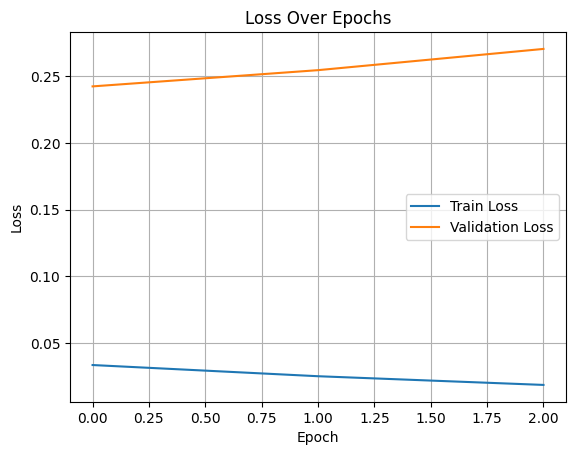

In [41]:
# Plot loss
print('Name: Selvarani S             ')
print('Register Number: 212224040301    ')
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()


In [43]:
i = 150
model.eval()

sample = X_test[i].unsqueeze(0).to(device)
output = model(sample)

preds = torch.argmax(output, dim=-1).squeeze().cpu().numpy()
true = y_test[i].numpy()
print('Name: Selvarani S             ')
print('Register Number: 212224040301    ')
print("\nWord\t\tTrue\tPred")
print("-" * 40)

for w_id, t, p in zip(X_test[i], y_test[i], preds):
    if w_id.item() != word2idx["ENDPAD"]:
        word = words[w_id.item() - 1]
        print(f"{word:<15} {idx2tag[t.item()]:<10} {idx2tag[p]}")

Name: Selvarani S             
Register Number: 212224040301    

Word		True	Pred
----------------------------------------
A               O          O
Saudi           B-org      B-org
Interior        I-org      I-org
Ministry        I-org      I-org
spokesman       O          O
says            O          O
three           O          O
French          B-gpe      B-gpe
nationals       O          O
have            O          O
been            O          O
killed          O          O
in              O          O
northwestern    O          O
Saudi           B-geo      B-geo
Arabia          I-geo      I-geo
.               O          O
